<a href="https://colab.research.google.com/github/badalsahu200ns-png/Projects/blob/main/Car_Market_Trends_Analysis_with_Car_Dekho_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data= pd.read_csv("Car Market Trends Analysis with Car Dekho Data.csv")

**Load the Dataset**

In [ ]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


first five rows of the dataset

In [ ]:
data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


last five rows of the dataset.

In [ ]:
from os import dup
#data quality check
data.shape

(299, 9)

To determine the number of rows and columns in the dataset.

In [ ]:
#column names
data.columns.to_list()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner']

To display all the column names in the dataset as a Python list.

In [ ]:
#To look at the variables in details
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Kms_Driven     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Seller_Type    299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 23.4+ KB


to get detailed information about the dataset.

In [ ]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


to identify the number of missing values in each column.

In [ ]:
#to check the statistical features of the data
data.describe(include='all')

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,299,299.000000,299.000000,299.000000,299.000000,299,299,299,299.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,193,260,NaN
mean,NaN,2013.615385,4.589632,7.541037,36916.752508,NaN,NaN,NaN,0.043478
std,NaN,2.896868,4.984240,8.567887,39015.170352,NaN,NaN,NaN,0.248720
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.850000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.510000,6.100000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.840000,48883.500000,NaN,NaN,NaN,0.000000


to obtain a statistical summary of the dataset.

In [ ]:
# Select the variables required for analysis

analysis_data = data[
    [
        "Year",
        "Kms_Driven",
        "Fuel_Type",
        "Transmission",
        "Car_Name",
        "Owner",
        "Selling_Price"
    ]
]

analysis_data.head()

,Year,Kms_Driven,Fuel_Type,Transmission,Car_Name,Owner,Selling_Price
0,2014,27000,Petrol,Manual,ritz,0,3.35
1,2013,43000,Diesel,Manual,sx4,0,4.75
2,2017,6900,Petrol,Manual,ciaz,0,7.25
3,2011,5200,Petrol,Manual,wagon r,0,2.85
4,2014,42450,Diesel,Manual,swift,0,4.60


In [ ]:
duplicate_count = data.duplicated().sum()
print('Duplicate Rows',duplicate_count)

Duplicate Rows 2


check for duplicate records

In [ ]:
data = data.drop_duplicates().copy()
print('Duplicates remaining',data.duplicated().sum())

Duplicates remaining 0


Remove Duplicates

to obtain a statistical summary of the dataset.

In [ ]:
missing = pd.DataFrame({
    'Missing Count': data.isna().sum(),
    'Missing %': (data.isna().mean() * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0]
missing.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %


calculate Missing %

In [ ]:
print(data.Fuel_Type.value_counts())

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64


To determine the frequency of each unique category in a categorical variable.

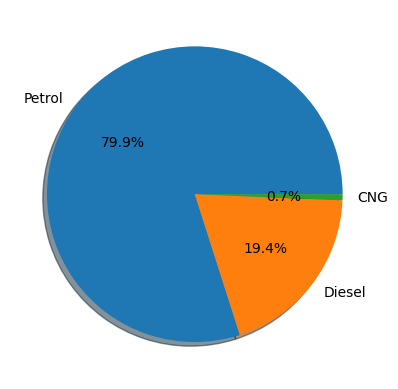

In [ ]:
plt.pie(data.Fuel_Type.value_counts(),labels=["Petrol","Diesel","CNG"],shadow=True,autopct='%1.1f%%')
plt.show()

pie chart for Fuel Type

<Axes: xlabel='Fuel_Type'>

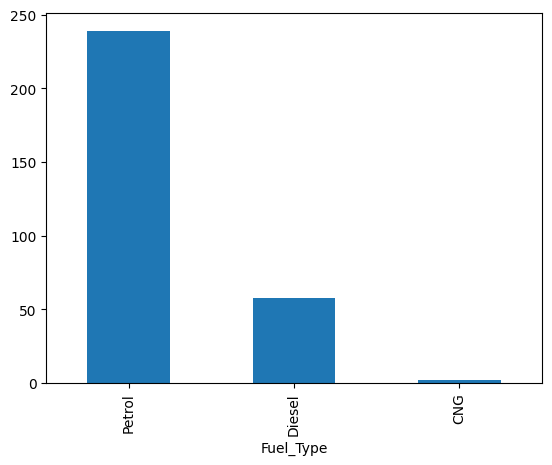

In [ ]:
data.Fuel_Type.value_counts().plot.bar()

Bar chart for Fuel Type

In [ ]:
# Car age / year
print("Year:")
print(data["Year"].head())

# Mileage / kilometers driven
print("\nKilometers Driven:")
print(data["Kms_Driven"].head())

# Fuel type
print("\nFuel Type:")
print(data["Fuel_Type"].value_counts())

# Transmission
print("\nTransmission:")
print(data["Transmission"].value_counts())

# Model / car name
print("\nCar Models:")
print(data["Car_Name"].head())

# Previous owners
print("\nPrevious Owners:")
print(data["Owner"].value_counts())

Year:
0    2014
1    2013
2    2017
3    2011
4    2014
Name: Year, dtype: int64

Kilometers Driven:
0    27000
1    43000
2     6900
3     5200
4    42450
Name: Kms_Driven, dtype: int64

Fuel Type:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Transmission:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

Car Models:
0       ritz
1        sx4
2       ciaz
3    wagon r
4      swift
Name: Car_Name, dtype: object

Previous Owners:
Owner
0    288
1     10
3      1
Name: count, dtype: int64


Identifying Key Variables for Car Price Analysis

In [ ]:
#checking wheather non numeric variables are categorical in nature
print(data.Car_Name.value_counts())

Car_Name
city                  26
corolla altis         16
verna                 14
brio                  10
fortuner              10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 98, dtype: int64


This helps us understand the frequency and distribution of car models in the dataset.

In [ ]:
current_year = 2026

data["Car_Age"] = current_year - data["Year"]

data[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


This new variable makes it easier to analyze the relationship between car age and selling price.

In [ ]:
# Create a copy for KPI calculations
kpi_data = data.copy()

# Calculate depreciation
kpi_data["Depreciation"] = (
    kpi_data["Present_Price"] - kpi_data["Selling_Price"]
)

# Calculate depreciation percentage
kpi_data["Depreciation_%"] = (
    kpi_data["Depreciation"] / kpi_data["Present_Price"]
) * 100

# Calculate KPIs
total_cars = len(kpi_data)

average_selling_price = kpi_data["Selling_Price"].mean()

average_present_price = kpi_data["Present_Price"].mean()

average_km_driven = kpi_data["Kms_Driven"].mean()

average_depreciation_percentage = kpi_data["Depreciation_%"].mean()


# Display KPI Cards
print(" Total Cars:", total_cars)
print(" Average Selling Price:", round(average_selling_price, 2), "Lakhs")
print(" Average Present Price:", round(average_present_price, 2), "Lakhs")
print(" Average KM Driven:", round(average_km_driven, 0), "KM")
print(" Average Depreciation %:", round(average_depreciation_percentage, 2), "%")

 Total Cars: 299
 Average Selling Price: 4.59 Lakhs
 Average Present Price: 7.54 Lakhs
 Average KM Driven: 36917.0 KM
 Average Depreciation %: 36.62 %


Key Performance Indicators

In [ ]:
from IPython.display import display, HTML

html = f"""
<div style="display:flex; gap:15px; flex-wrap:wrap;">

<div style="padding:20px; border:1px solid #ddd; border-radius:10px; min-width:160px;">
<h3> Total Cars</h3>
<h2>{total_cars:,}</h2>
</div>

<div style="padding:20px; border:1px solid #ddd; border-radius:10px; min-width:160px;">
<h3> Avg Selling Price</h3>
<h2>₹{average_selling_price:.2f} L</h2>
</div>

<div style="padding:20px; border:1px solid #ddd; border-radius:10px; min-width:160px;">
<h3> Avg Present Price</h3>
<h2>₹{average_present_price:.2f} L</h2>
</div>

<div style="padding:20px; border:1px solid #ddd; border-radius:10px; min-width:160px;">
<h3> Avg KM Driven</h3>
<h2>{average_km_driven:,.0f} KM</h2>
</div>

<div style="padding:20px; border:1px solid #ddd; border-radius:10px; min-width:160px;">
<h3> Avg Depreciation</h3>
<h2>{average_depreciation_percentage:.2f}%</h2>
</div>

</div>
"""

display(HTML(html))

visual KPI cards